In [20]:
import pandas as pd
import numpy as np
import re

file = r'..\..\results\Results_CO2Liq.xlsx'

In [21]:
df_result = pd.read_excel(file, sheet_name='ResultT')
df_duals = pd.read_excel(file, sheet_name='Duals')
df_el_price = pd.read_excel(file, sheet_name='ResultA')

In [22]:
df_duals
duals = -df_duals.iloc[:, 3].values
duals

array([91.94474283, 91.94474283, 91.94474283, ..., 82.96535342,
       83.37482645, 83.10184443], shape=(8760,))

In [23]:
df_el_price
el_price = df_el_price.iloc[4, 3:].values
el_price

array([np.float64(41.72), np.float64(23.47), np.float64(9.32), ...,
       np.float64(46.57), np.float64(46.44), np.float64(45.68)],
      shape=(8760,), dtype=object)

In [24]:
# 2) Find the time columns in df_result and sort them numerically (T0001..T8760)
time_cols = [c for c in df_result.columns if re.fullmatch(r'T\d+', str(c))]
time_cols = sorted(time_cols, key=lambda x: int(x[1:]))

In [25]:
# 3) Build a new row aligned to df_result's columns
new_row = pd.Series(index=df_result.columns, dtype=object)
new_row['Result'] = 'ElPrice'
new_row['tech']   = pd.NA       # empty
new_row['energy'] = 'Electricity'
new_row.loc[time_cols] = el_price[:len(time_cols)]

df_result = pd.concat([pd.DataFrame([new_row]), df_result], ignore_index=True)

new_row = pd.Series(index=df_result.columns, dtype=object)
new_row['Result'] = 'Dual Value'
new_row['tech']   = pd.NA       # empty
new_row['energy'] = 'CO2Liq'
new_row.loc[time_cols] = duals[:len(time_cols)]

df_result = pd.concat([pd.DataFrame([new_row]), df_result], ignore_index=True)
df_result

,Result,tech,energy,T0001,T0002,T0003,T0004,T0005,T0006,T0007,...,T8751,T8752,T8753,T8754,T8755,T8756,T8757,T8758,T8759,T8760
0,Dual Value,<NA>,CO2Liq,91.944743,91.944743,91.944743,91.944743,91.944743,91.944743,91.944743,...,82.965353,82.965353,82.965353,82.965353,82.965353,82.965353,82.965353,82.965353,83.374826,83.101844
1,ElPrice,<NA>,Electricity,41.720000,23.470000,9.320000,3.490000,5.990000,0.850000,-3.850000,...,47.140000,47.730000,48.410000,49.380000,48.880000,47.250000,46.940000,46.570000,46.440000,45.680000
2,Operation,WindTurbine,Electricity,44.291520,46.142460,12.911514,12.911514,12.911514,0.000000,0.000000,...,20.496840,18.995340,17.603040,16.680300,15.184260,13.278720,12.050220,12.263160,13.906620,15.686580
3,Operation,WindTurbine,Wind,-46.506096,-48.449583,-13.557090,-13.557090,-13.557090,0.000000,0.000000,...,-21.521682,-19.945107,-18.483192,-17.514315,-15.943473,-13.942656,-12.652731,-12.876318,-14.601951,-16.470909
4,Operation,SolarPV,Electricity,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.621000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,Variable_OM_cost_EUR,CO2Compressor,system_cost,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
106,Variable_OM_cost_EUR,CO2Storage,system_cost,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
107,Variable_OM_cost_EUR,HydrogenStorage,system_cost,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
108,Variable_OM_cost_EUR,CO2Liquefaction,system_cost,9.437100,9.437100,9.437100,9.437100,9.437100,9.437100,9.437100,...,2.103528,2.103528,2.103528,2.103528,2.103528,2.103528,2.103528,2.103528,7.702836,7.702836


In [26]:
df_slice = df_result.loc[:, list(df_result.columns[:3]) + list(df_result.loc[:, 'T5700':'T5780'].columns)]


In [27]:
#keep only operation data
df_operation = df_slice[df_slice['Result'] .isin (['ElPrice', 'Dual Value', 'Operation'])]

In [44]:
#keep relevant energy carriers
carriers = ['Electricity', 'HydrogenComp', 'CO2', 'CO2Liq', 'Methanol']
df_operation_energy = df_operation[df_operation['energy'].isin(carriers)].reset_index(drop=True)
value_cols = [c for c in df_operation_energy.columns if c.startswith('T')]
df_operation_energy.loc[df_operation_energy['tech']=='MethanolSynthesis', value_cols] *= -1  # invert sign for MethanolSynthesis
df_operation_energy

,Result,tech,energy,T5700,T5701,T5702,T5703,T5704,T5705,T5706,...,T5771,T5772,T5773,T5774,T5775,T5776,T5777,T5778,T5779,T5780
0,Dual Value,<NA>,CO2Liq,89.615524,89.615524,89.615524,89.615524,89.615524,70.060019,-0.00000,...,90.142640,89.966937,89.966937,89.966937,89.966937,89.966937,89.966937,90.462316,89.966937,89.966937
1,ElPrice,<NA>,Electricity,54.310000,52.770000,52.180000,51.790000,56.860000,66.420000,69.37000,...,63.410000,55.520000,53.020000,51.320000,51.110000,50.820000,57.400000,64.300000,75.370000,70.330000
2,Operation,WindTurbine,Electricity,5.192460,5.558280,5.814900,5.847660,5.389020,5.105100,6.13704,...,4.684680,5.935020,7.261800,8.146320,8.397480,8.315580,7.310940,5.798520,5.678400,6.153420
3,Operation,SolarPV,Electricity,15.336000,14.094000,12.015000,9.207000,6.237000,3.321000,0.99900,...,13.581000,14.013000,12.987000,10.719000,8.343000,5.778000,3.159000,0.918000,0.000000,0.000000
4,Operation,ElectricStorage,Electricity,0.000000,0.000000,0.000000,-1.684211,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,-0.502145,-1.182066,0.000000,0.000000,1.600000,0.000000
5,Operation,MethanolSynthesis,CO2Liq,1.632458,1.632458,1.632458,1.632458,1.533801,0.652983,-0.00000,...,1.632458,1.632458,1.632458,1.632458,1.632458,1.632458,1.632458,1.632458,1.632458,1.632458
6,Operation,MethanolSynthesis,Electricity,0.116604,0.116604,0.116604,0.116604,0.109557,0.046642,-0.00000,...,0.116604,0.116604,0.116604,0.116604,0.116604,0.116604,0.116604,0.116604,0.116604,0.116604
7,Operation,MethanolSynthesis,HydrogenComp,0.223880,0.223880,0.223880,0.223880,0.210350,0.089552,-0.00000,...,0.223880,0.223880,0.223880,0.223880,0.223880,0.223880,0.223880,0.223880,0.223880,0.223880
8,Operation,MethanolSynthesis,Methanol,-1.166042,-1.166042,-1.166042,-1.166042,-1.095572,-0.466417,-0.00000,...,-1.166042,-1.166042,-1.166042,-1.166042,-1.166042,-1.166042,-1.166042,-1.166042,-1.166042,-1.166042
9,Operation,Electrolysis_12_1,Electricity,-5.999984,-5.999984,-5.999984,-5.999984,-5.999984,-1.199997,0.00000,...,-5.999984,-5.999984,-5.999984,-5.999984,-5.999984,-5.999984,-5.999984,-1.199997,0.000000,-1.199997


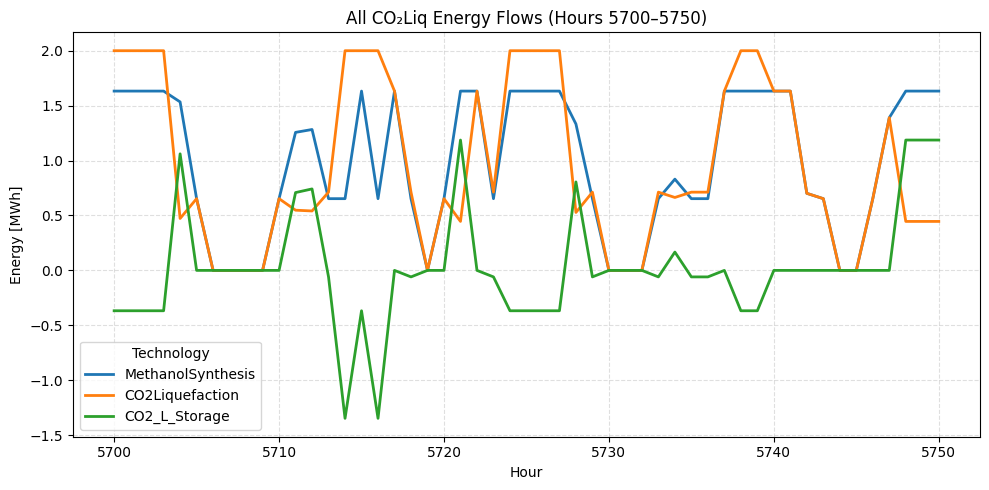

In [42]:
import matplotlib.pyplot as plt
import re
import pandas as pd

# --- 1) Define the time window ---
start_col, end_col = 'T5700', 'T5750'
time_cols = [c for c in df_operation_energy.columns if re.fullmatch(r'T\d+', str(c))]
time_cols = sorted(time_cols, key=lambda x: int(x[1:]))
time_window = [c for c in time_cols if start_col <= c <= end_col]
x = [int(c[1:]) for c in time_window]

if not time_window:
    raise ValueError("Requested T-range not found in df_operation_energy.")

# --- 2) Filter all rows with energy = 'CO2Liq' and Result = 'Operation' ---
mask_co2liq = (
    (df_operation_energy['Result'] == 'Operation') &
    (df_operation_energy['energy'] == 'CO2Liq')
)
df_co2liq = df_operation_energy.loc[mask_co2liq]

if df_co2liq.empty:
    raise ValueError("No rows with energy='CO2Liq' found in df_operation_energy.")

# --- 3) Plot all CO2Liq techs ---
fig, ax = plt.subplots(figsize=(10, 5))

for _, row in df_co2liq.iterrows():
    tech = row['tech']
    # values = row[time_window].astype(float).abs().values
    values = row[time_window].astype(float).values
    ax.plot(x, values, linewidth=2, label=tech)

# --- 4) Formatting ---
ax.set_xlabel('Hour')
ax.set_ylabel('Energy [MWh]')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(title='Technology', loc='best')
plt.title(f"All CO₂Liq Energy Flows (Hours {start_col[1:]}–{end_col[1:]})")

fig.tight_layout()
plt.show()
